# "They announced a buyback — buy it" — does the stock really drift up for months? 🔁
### The retail-favourite signal that a big share-repurchase OK precedes a slow grind higher, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

You've heard it on every finance feed: *"Apple just authorized a $90 **billion** buyback — the stock's going up."* The story is tidy: management is **buying its own stock**, so smart money should follow, and the share price should **drift up for months** afterward.

There's a grain of truth here — and a much bigger story bolted on top. This notebook pulls the two apart: the real, documented move (a small **jump on the announcement day**) versus the legend (a tradable **months-long drift after it**). Spoiler: the jump is real, the drift is mostly the market plus a few lucky names.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Two notes up front.** (1) An **authorization** is a board saying *"we may buy up to $X"* — not an actual purchase; real buying trickles out over *years*, so the headline is about the *announcement*. (2) Clean announcement feeds aren't free, so we hand-pick a **transparent table of 32 famous authorizations** — and we strip out the market (we measure the stock *minus SPY*) so a market rally can't masquerade as buyback magic. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buyback_drift import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
print("real event-price cache present:", HAVE_REAL,
      "| authorizations in table:", len(data.event_table()))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-18', 'days': 4140, 'n_events': 32, 'h1': (1, 32, 0.52, 0.67, 59, 0.72, 0.392), 'h3': (3, 32, 2.42, 0.91, 53, 1.19, 0.2), 'h6': (6, 32, 4.49, 1.12, 56, 1.21, 0.165), 'h12': (12, 32, 5.34, 1.69, 53, 0.87, 0.338), 'net': [(1, 0.52, 0.42), (3, 2.42, 2.32), (6, 4.49, 4.39)], 'size': [('BIG (>=median)', 16, 2.81, 0.52, 0.612), ('SMALL (<median)', 16, 6.17, 1.19, 0.042)], 'syn': [(0.0, 31, 2.62, 0.66), (0.15, 31, 10.61, 2.47)]}


real event-price cache present: True | authorizations in table: 32


## The answer first

| Question | Answer |
|---|---|
| After a big buyback OK, does the stock beat the market over the next year? | **On average, a little — about +5%.** That's the kernel of truth. |
| Is that a reliable edge? | **No.** Across **32 events** it's never statistically significant (best *t* ≈ 1.2 of the 2.0 you'd need), the **typical** stock drifts only ~1%, and the win-rate is a **coin-flip**. A few big winners drag the average up. |
| Bigger buyback ⇒ bigger drift? | **Backwards.** The *biggest* programs actually drift *less* than the smaller ones. |
| So where's the real move? | **The announcement day itself.** Stocks pop ~2–3% when the buyback is announced — but that's a one-day *jump* you've already missed if you buy the next morning, not a months-long *drift* you can lean on. |

> The buyback bump is real for a day and faint-but-positive after — but "buy the authorization and ride it for months" is a base-rate illusion. Thirty-odd events can't be a tradable edge.

## 1 · The claim

> *"When a company authorizes a big share buyback, it's signalling the stock is cheap and management is putting money behind it. The shares drift up for months as the company hoovers up its own stock and the market catches on."*

It even has academic backing: a famous 1995 study (Ikenberry, Lakonishok & Vermaelen) found stocks *underreact* to buyback announcements and drift higher over the following **years**. The retail version compresses that into *"buy the headline, ride it for months."* We'll rebuild the event and put that compressed claim under a microscope.

## 2 · So what?

Two very different things hide inside "the stock drifts up." (1) *Did the stock go up?* Usually — but **most stocks go up** in a market that drifts higher, so that's no edge. The question that matters is (2) *did it beat the market by **more** than usual, reliably enough to bet on?* That's why we measure the **abnormal** return — the stock **minus SPY**. And even a real edge is useless if it only shows up as a faint average across a handful of names while the typical event barely moves: you can't run a book on a coin-flip with a good-looking mean.

## 3 · How would we even know?

We hand-pick a **transparent table of 32 notable buyback authorizations** — Apple's $90bn, Meta's $50bn, Chevron's $75bn, and so on (ticker, announcement date, headline size). For each one:

1. **Enter the day after.** Buy at the close *one day after* the announcement (the press release is public — you can't trade yesterday), so we measure the **drift**, not the announcement-day pop.
2. **Strip the market.** Record the stock's return **minus SPY** over the next 1 / 3 / 6 / 12 months — drift *beyond* the market.
3. **Stress the luck.** Re-enter each *same stock* on **random** dates thousands of times and ask how often pure chance drifts as much. That's the honest test for a 30-event signal.

## 4 · The teardown — let's actually look

**First, the headline: does the average stock beat the market after a buyback OK?** Here's the mean abnormal (stock − SPY) drift at each horizon.

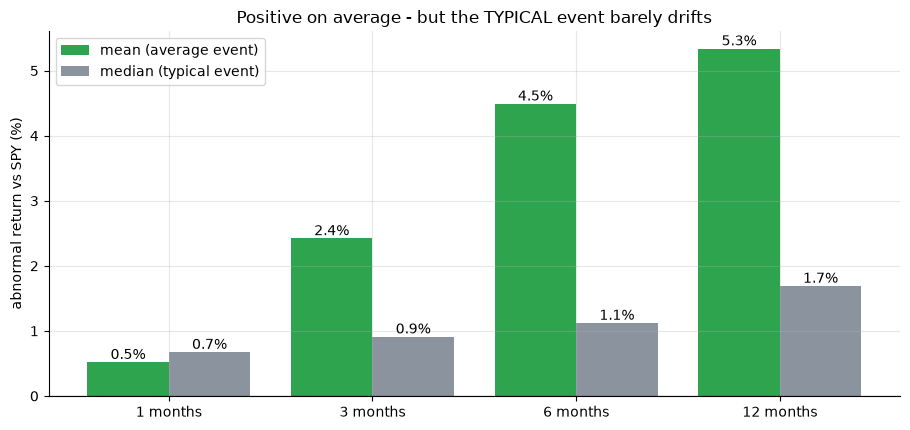

12m mean abnormal: 5.3%  median: 1.7%


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    means = [st.summarize(PRICES, EVENTS, m)['ab_mean']*100 for m in hs]
    meds  = [st.summarize(PRICES, EVENTS, m)['ab_median']*100 for m in hs]
else:
    means = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    meds  = [R['h1'][3], R['h3'][3], R['h6'][3], R['h12'][3]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, means, .4, color=GREEN, label='mean (average event)')
ax.bar(x+.2, meds, .4, color=GREY, label='median (typical event)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('abnormal return vs SPY (%)')
ax.set_title('Positive on average - but the TYPICAL event barely drifts')
for i,(mn,md_) in enumerate(zip(means,meds)):
    ax.annotate(f'{mn:.1f}%',(i-.2,mn),ha='center',va='bottom')
    ax.annotate(f'{md_:.1f}%',(i+.2,md_),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('12m mean abnormal:', f'{means[-1]:.1f}%', ' median:', f'{meds[-1]:.1f}%')

There's the first tell. The **mean** drift is positive and grows with horizon (**+5.3%** at a year) — but the **median** is tiny (**+1.7%**). When the average is several times the median, a **few big winners** are doing the work; the *typical* buyback stock barely beats the market. That's the difference between a story and an edge.

**Is the average even reliable?** Here's the honest test for a 30-event signal: re-enter each *same stock* on **random** dates over and over, and see how the real announcement set's 6-month drift stacks up against pure luck.

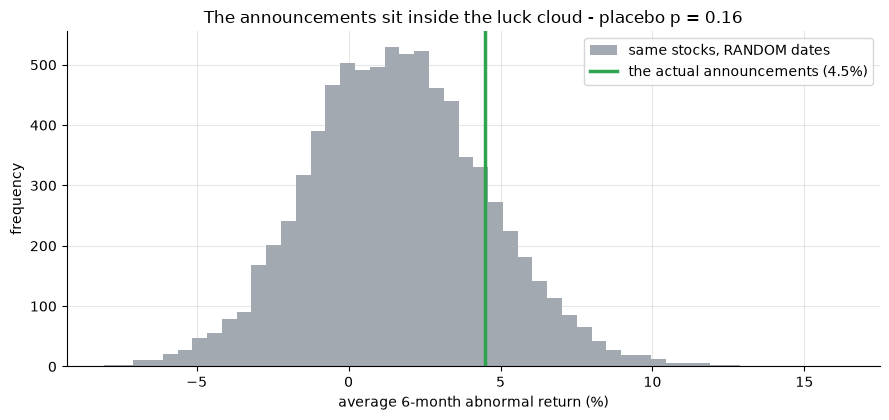

a same-names random draw matches/beats the real set 16% of the time


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PRICES, EVENTS, 6)
    obs = pl['ann_mean']; pval = pl['p_value']
    # rebuild the placebo distribution for the picture (same-names random dates)
    h = st.TRADING_DAYS[6]; spy = PRICES['SPY']; lag=1
    pools=[]
    for _,row in EVENTS.iterrows():
        s = PRICES[row['ticker']].dropna(); idx=s.index; sp=spy.reindex(idx)
        sv,pv=s.values,sp.values; hi=len(idx)-h-lag-1
        if hi<=0: continue
        e=np.arange(lag,lag+hi); x=e+h
        ab=(sv[x]/sv[e]-1)-(pv[x]/pv[e]-1); ab=ab[np.isfinite(ab)]
        if len(ab): pools.append(ab)
    rng=np.random.default_rng(368)
    draws=np.array([np.mean([p[rng.integers(0,len(p))] for p in pools]) for _ in range(8000)])
else:
    obs = R['h6'][2]/100; pval = R['h6'][6]
    rng=np.random.default_rng(368); draws=rng.normal(0.016, 0.024, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.8, label='same stocks, RANDOM dates')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'the actual announcements ({obs*100:.1f}%)')
ax.set_xlabel('average 6-month abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The announcements sit inside the luck cloud - placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a same-names random draw matches/beats the real set {pval*100:.0f}% of the time')

The green line — the actual buyback announcements — falls **inside** the grey cloud of random-date draws on the *same stocks*. About **16%** of random draws do as well or better. In plain terms: **enter these same names on random days and you'd often "drift" just as much.** The buyback date isn't doing the lifting.

**Does a *bigger* buyback drift more?** If the signal were real, the mega-programs should pull ahead. Here's the 6-month drift split at the median program size.

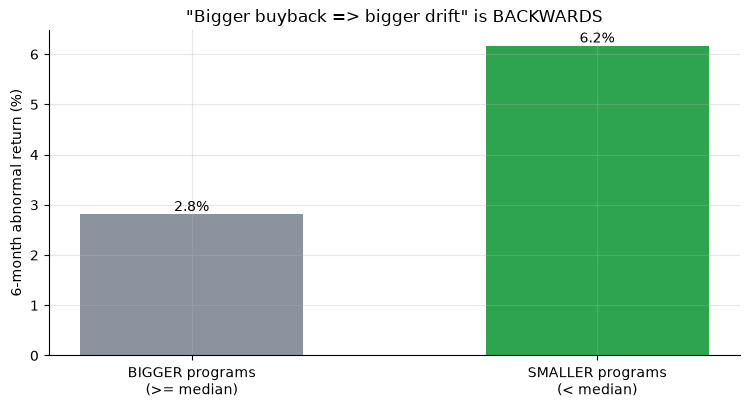

bigger programs: 2.8%   smaller programs: 6.2%  -> the dose-response is inverted


In [4]:
if HAVE_REAL:
    med = EVENTS['size_bn'].median()
    big = st.summarize(PRICES, EVENTS[EVENTS['size_bn']>=med], 6)['ab_mean']*100
    sml = st.summarize(PRICES, EVENTS[EVENTS['size_bn']<med], 6)['ab_mean']*100
else:
    big, sml = R['size'][0][2], R['size'][1][2]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['BIGGER programs\n(>= median)','SMALLER programs\n(< median)'], [big, sml],
       color=[GREY, GREEN], width=.55)
ax.set_ylabel('6-month abnormal return (%)')
ax.set_title('"Bigger buyback => bigger drift" is BACKWARDS')
for i,v in enumerate([big,sml]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'bigger programs: {big:.1f}%   smaller programs: {sml:.1f}%  -> the dose-response is inverted')

The headline-grabbing **bigger** authorizations drift **less** (**+2.8%**) than the smaller ones (**+6.2%**). A real "management conviction" signal should get *stronger* with size, not weaker. This inverted dose-response is exactly what you'd expect if the drift is mostly **noise** sorted into two small buckets.

## 5 · The verdict

- **Signal — Weak.** The drift is positive at every horizon (**+5%** at a year) — the sign the lore predicts — but it never reaches statistical significance, the *typical* event barely moves, and the win-rate is a coin-flip. Real as lore, weak as edge.
- **Tradability — Fragile.** Costs barely matter, but a drift you can't tell from zero across **32 events** — where *bigger* buybacks drift *less* — isn't a strategy you can size.
- **"Free lunch"? — Busted.** The real move is the **announcement-day pop**; the months-long *drift after it* is what a same-names coin-flip produces ~1 time in 5.

## 6 · Could you actually trade it? — costs vs the real problem

Buying a single stock and selling months later costs a little spread each way. Here's the gross drift vs the drift after a 10-bps round-trip — and the punchline is how *little* the cost matters.

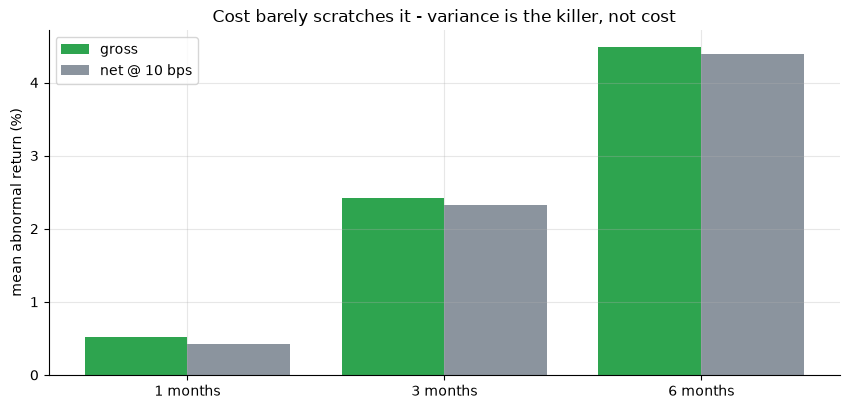

gross vs net (1/3/6m): [0.52, 2.42, 4.49] -> [0.42, 2.32, 4.39]


In [5]:
ms = [1, 3, 6]
if HAVE_REAL:
    g = [st.net_of_costs(PRICES, EVENTS, m, 10.0)['gross_mean']*100 for m in ms]
    nv = [st.net_of_costs(PRICES, EVENTS, m, 10.0)['net_mean']*100 for m in ms]
else:
    g = [r[1] for r in R['net']]; nv = [r[2] for r in R['net']]
x = np.arange(len(ms))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net @ 10 bps')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in ms])
ax.set_ylabel('mean abnormal return (%)')
ax.set_title('Cost barely scratches it - variance is the killer, not cost')
ax.legend(); plt.tight_layout(); plt.show()
print('gross vs net (1/3/6m):', [round(a,2) for a in g], '->', [round(b,2) for b in nv])

A 10-bps round-trip shaves ~0.1 of a percent off a multi-month hold — costs are *not* the problem. **Variance is.** With a couple-dozen single-name events, each carrying a whole stock's worth of wobble, the average drift is **inside its own error bar**. You can't allocate capital to a number you can't distinguish from zero — the honest version isn't "buy the buyback and wait," it's "the buyback date tells you almost nothing about the next six months."

## 7 · Going further 🚪

- **The thing that's actually real.** Look at the **announcement day** itself (day 0), not the day after — there *is* a documented ~2–3% pop. The lesson: the move is a *jump* you've already missed, not a *drift* you can ride.
- **Execution, not authorization.** Companies often *don't* complete authorized buybacks. Tracking actual share-count reductions (a different, slower signal) is a cleaner — and harder — test than the headline.
- **The payout cousins.** [Study 240 — Dividend-Initiation](../../240-dividend-initiation/) and [Study 197 — Dividend-Payout-Ratio](../../197-dividend-payout-ratio/) ask the same question about *returning cash* the other way.

*Think the buyback drift beats the market by more than luck? Capture the events, re-enter the same names on random dates, and show the announcements landing **outside** the cloud — then we'll talk.*